<a href="https://colab.research.google.com/github/ahcamachod/2279-data-science-analisis-prevision-de-series-temporales/blob/proyecto-final/analisis_y_prevision_de_series_temporales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Science: Análisis y previsión de Series Temporales**



##**Clase 1: Preparando y procesando los datos**

###**Importando los datos**

> Consulta la documentación de la biblioteca Pandas [aquí](https://pandas.pydata.org/).

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/ahcamachod/2279-data-science-analisis-prevision-de-series-temporales/refs/heads/main/bicicletas.csv',sep=',')

In [3]:
df.head()

,fecha_hora,conteo,temperatura,sensacion_termica,humedad,velocidad_viento,clima,festivo,fin_de_semana,estacion
0,2023-01-04 00:00:00,182,3.0,2.0,93.0,6.0,Nublado,No,Sí,Invierno
1,2023-01-04 01:00:00,138,NaN,NaN,93.0,5.0,Cielo abierto,No,Sí,Invierno
2,2023-01-04 02:00:00,134,2.5,2.5,96.5,0.0,Cielo abierto,No,Sí,Invierno
3,2023-01-04 03:00:00,72,2.0,2.0,100.0,0.0,Cielo abierto,No,Sí,Invierno
4,2023-01-04 04:00:00,47,NaN,NaN,93.0,6.5,Cielo abierto,No,Sí,Invierno


###**Tratando los datos nulos**

In [4]:
df.shape

(17429, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17429 entries, 0 to 17428
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha_hora         17429 non-null  object 
 1   conteo             17429 non-null  int64  
 2   temperatura        17406 non-null  float64
 3   sensacion_termica  17406 non-null  float64
 4   humedad            17429 non-null  float64
 5   velocidad_viento   17429 non-null  float64
 6   clima              17429 non-null  object 
 7   festivo            17429 non-null  object 
 8   fin_de_semana      17429 non-null  object 
 9   estacion           17429 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 1.3+ MB


In [6]:
df.isnull().sum()

,0
fecha_hora,0
conteo,0
temperatura,23
sensacion_termica,23
humedad,0
velocidad_viento,0
clima,0
festivo,0
fin_de_semana,0
estacion,0


>Consulta la documentación detallada del método *interpolate()* de la biblioteca Pandas [aquí](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.interpolate.html).

In [7]:
df['temperatura'] = df['temperatura'].interpolate(method='linear')
df['sensacion_termica'] = df['sensacion_termica'].interpolate(method='linear')

In [8]:
df.head(10)

,fecha_hora,conteo,temperatura,sensacion_termica,humedad,velocidad_viento,clima,festivo,fin_de_semana,estacion
0,2023-01-04 00:00:00,182,3.00,2.00,93.0,6.0,Nublado,No,Sí,Invierno
1,2023-01-04 01:00:00,138,2.75,2.25,93.0,5.0,Cielo abierto,No,Sí,Invierno
2,2023-01-04 02:00:00,134,2.50,2.50,96.5,0.0,Cielo abierto,No,Sí,Invierno
3,2023-01-04 03:00:00,72,2.00,2.00,100.0,0.0,Cielo abierto,No,Sí,Invierno
4,2023-01-04 04:00:00,47,2.00,2.00,93.0,6.5,Cielo abierto,No,Sí,Invierno
5,2023-01-04 05:00:00,46,2.00,2.00,93.0,4.0,Cielo abierto,No,Sí,Invierno
6,2023-01-04 06:00:00,51,1.00,-1.00,100.0,7.0,Parcialmente nublado,No,Sí,Invierno
7,2023-01-04 07:00:00,75,1.00,-1.00,100.0,7.0,Parcialmente nublado,No,Sí,Invierno
8,2023-01-04 08:00:00,131,1.50,-1.00,96.5,8.0,Parcialmente nublado,No,Sí,Invierno
9,2023-01-04 09:00:00,301,2.00,-0.50,100.0,9.0,Nublado,No,Sí,Invierno


###**Identificando y eliminando datos duplicados**

In [9]:
df.duplicated().sum()

np.int64(15)

In [10]:
duplicados= df.duplicated(keep=False)
filas_duplicadas =df[duplicados]
filas_duplicadas.sort_values(by='fecha_hora')

,fecha_hora,conteo,temperatura,sensacion_termica,humedad,velocidad_viento,clima,festivo,fin_de_semana,estacion
519,2023-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,No,Sí,Invierno
17422,2023-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,No,Sí,Invierno
869,2023-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,No,No,Invierno
17417,2023-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,No,No,Invierno
3655,2023-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,No,No,Verano
17425,2023-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,No,No,Verano
4167,2023-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,No,Sí,Verano
17421,2023-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,No,Sí,Verano
4658,2023-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,No,No,Verano
17418,2023-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,No,No,Verano


>Consulta la documentación del método *drop_duplicates()* de la biblioteca Pandas [aquí](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop_duplicates.html).

In [11]:
df_limpio = df.drop_duplicates()

In [12]:
df_limpio.shape

(17414, 10)

##**Clase 2: Explorando los datos numéricos**

###**Obteniendo las estadísticas descriptivas**

In [14]:
df_limpio.describe()

,conteo,temperatura,sensacion_termica,humedad,velocidad_viento
count,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000
mean,1143.101642,12.468206,11.521080,72.324954,15.913063
std,1085.108068,5.571670,6.614799,14.313186,7.894570
min,0.000000,-1.500000,-6.000000,20.500000,0.000000
25%,257.000000,8.000000,6.000000,63.000000,10.000000
50%,844.000000,12.500000,12.500000,74.500000,15.000000
75%,1671.750000,16.000000,16.000000,83.000000,20.500000
max,7860.000000,34.000000,34.000000,100.000000,56.500000


###**Analizando las distribuciones**

> La documentación de las bibliotecas de visualización puede ser consultada a través de los siguientes links:
> * [Seaborn: Statistical Data Visualization](https://seaborn.pydata.org/)
> * [Matplotlib: Visualization with Python](https://matplotlib.org/)

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

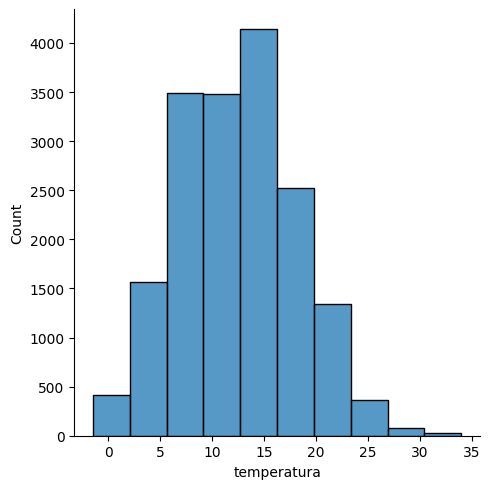

In [17]:
sns.displot(df_limpio, x='temperatura',bins=10)
plt.show()

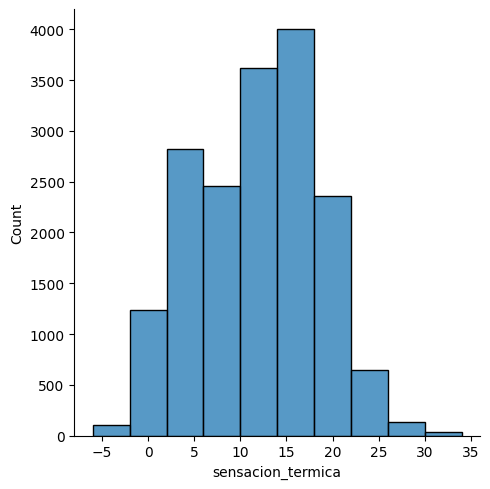

In [18]:
sns.displot(df_limpio, x='sensacion_termica',bins=10)
plt.show()

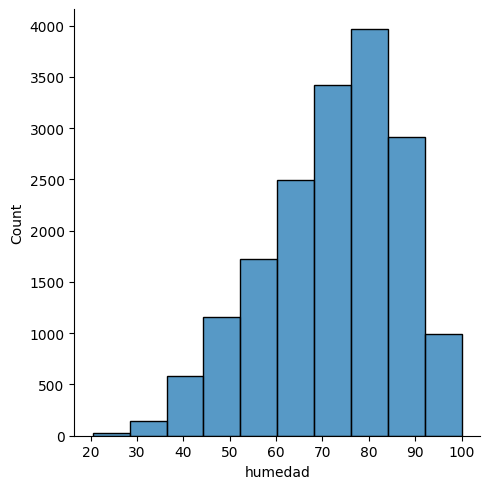

In [19]:
sns.displot(df_limpio, x='humedad',bins=10)
plt.show()

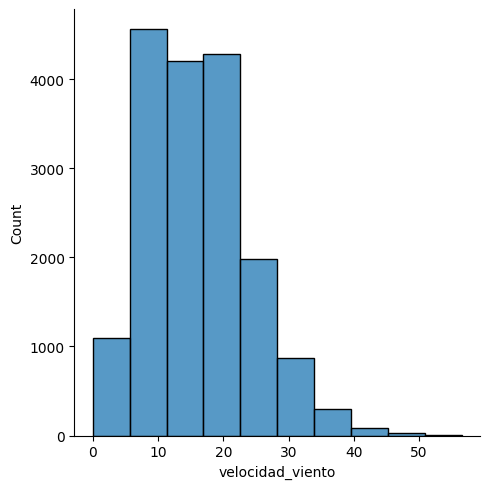

In [20]:
sns.displot(df_limpio, x='velocidad_viento',bins=10)
plt.show()

###**Investigando relaciones entre variables**

> **Prompt:** Genera 4 gráficos de tipo scatterplot utilizando python con las bibliotecas seaborn y matplotlib, para las variables temperatura, sensacion_termica, humedad, velocidad_viento con la columna conteo en el eje "y". Coloca los gráficos en la posición 2X2. Cada gráfico debe tener su respectivo título.

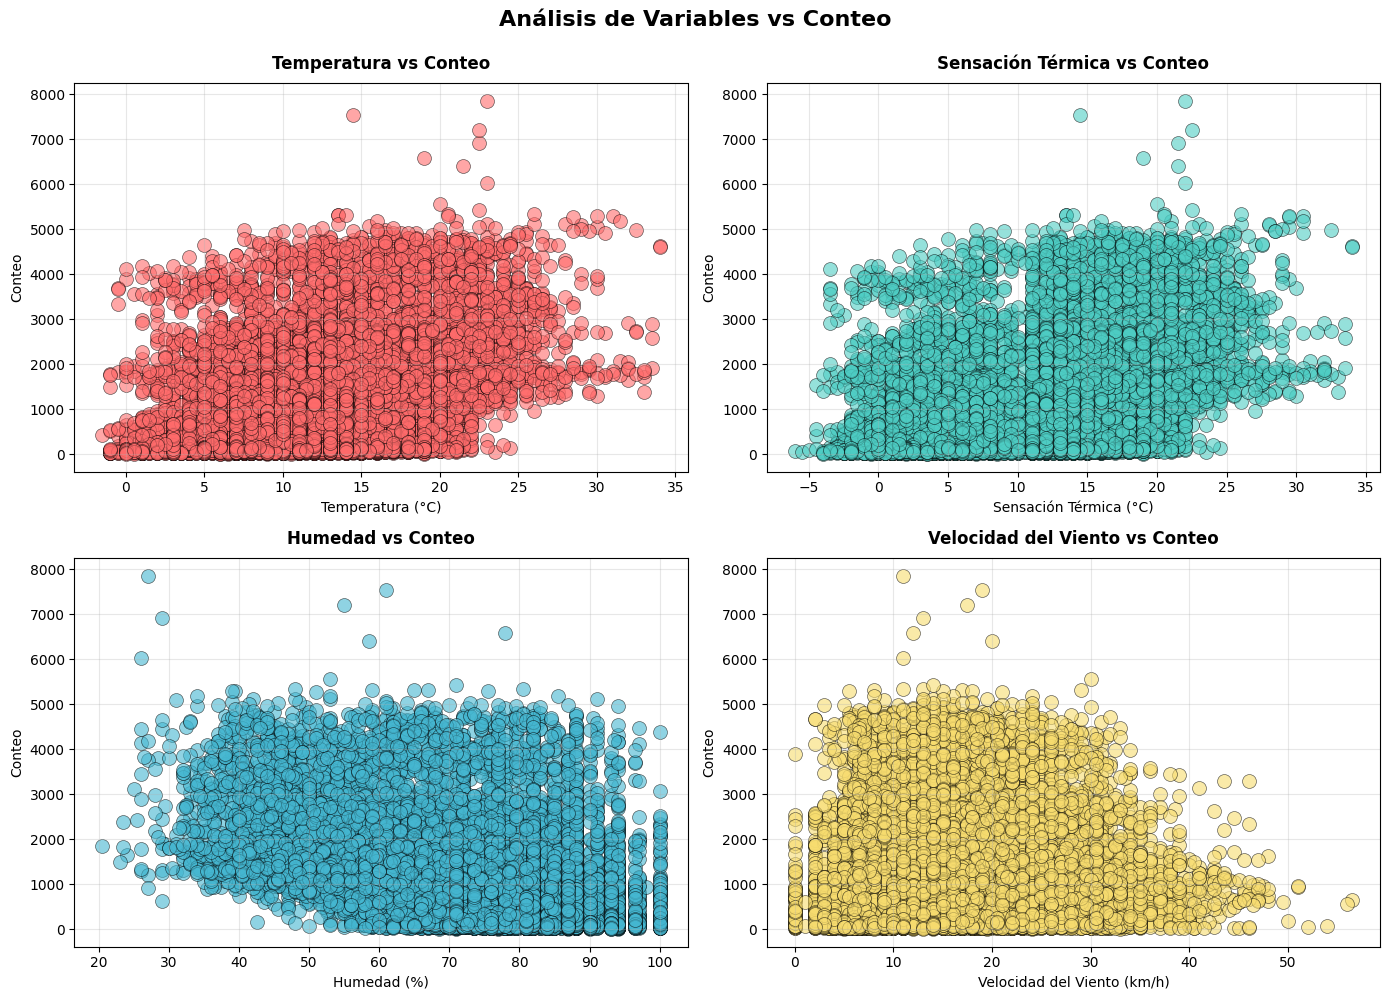

In [21]:
# Crear figura con disposición 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis de Variables vs Conteo', fontsize=16, fontweight='bold', y=0.995)

# Gráfico 1: Temperatura vs Conteo (posición [0,0])
sns.scatterplot(data=df_limpio, x='temperatura', y='conteo', ax=axes[0, 0],
                s=100, alpha=0.6, color='#FF6B6B', edgecolor='black', linewidth=0.5)
axes[0, 0].set_title('Temperatura vs Conteo', fontsize=12, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Temperatura (°C)', fontsize=10)
axes[0, 0].set_ylabel('Conteo', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Sensación Térmica vs Conteo (posición [0,1])
sns.scatterplot(data=df_limpio, x='sensacion_termica', y='conteo', ax=axes[0, 1],
                s=100, alpha=0.6, color='#4ECDC4', edgecolor='black', linewidth=0.5)
axes[0, 1].set_title('Sensación Térmica vs Conteo', fontsize=12, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('Sensación Térmica (°C)', fontsize=10)
axes[0, 1].set_ylabel('Conteo', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Humedad vs Conteo (posición [1,0])
sns.scatterplot(data=df_limpio, x='humedad', y='conteo', ax=axes[1, 0],
                s=100, alpha=0.6, color='#45B7D1', edgecolor='black', linewidth=0.5)
axes[1, 0].set_title('Humedad vs Conteo', fontsize=12, fontweight='bold', pad=10)
axes[1, 0].set_xlabel('Humedad (%)', fontsize=10)
axes[1, 0].set_ylabel('Conteo', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Velocidad del Viento vs Conteo (posición [1,1])
sns.scatterplot(data=df_limpio, x='velocidad_viento', y='conteo', ax=axes[1, 1],
                s=100, alpha=0.6, color='#F7DC6F', edgecolor='black', linewidth=0.5)
axes[1, 1].set_title('Velocidad del Viento vs Conteo', fontsize=12, fontweight='bold', pad=10)
axes[1, 1].set_xlabel('Velocidad del Viento (km/h)', fontsize=10)
axes[1, 1].set_ylabel('Conteo', fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

# Ajustar espaciado entre gráficos
plt.tight_layout()
plt.show()

###**Examinando la correlación entre las variables**

La correlación es una medida estadística que describe la relación entre dos variables. Existen diferentes tipos de correlación, pero la correlación de Pearson es una de las más comunes. La correlación de Pearson mide la fuerza y la dirección de una relación lineal entre dos variables. Produce un valor de correlación que varía de -1 a 1.

>Consulta la documentación detallada del método *corr()* de la biblioteca Pandas [aquí](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html).

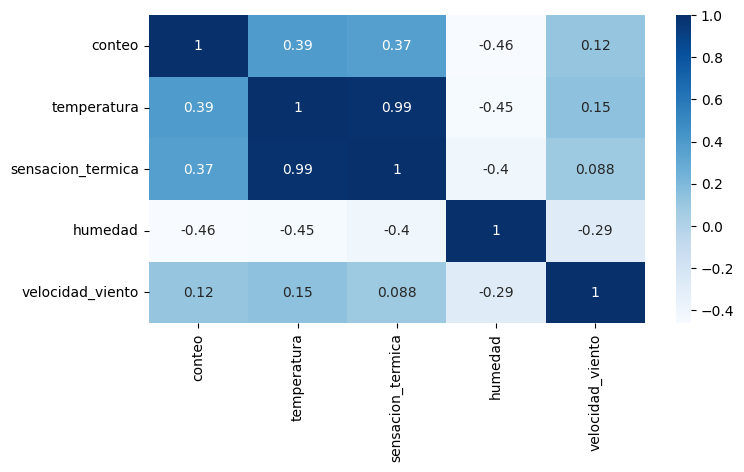

In [22]:
plt.figure(figsize=(8,4))
sns.heatmap(df_limpio.corr(numeric_only=True),annot=True,cmap='Blues')
plt.show()

##**Clase 3: Explorando los datos categóricos**

###**Obteniendo las estadísticas descriptivas**

In [23]:
df_limpio.describe(include=[object])

,fecha_hora,clima,festivo,fin_de_semana,estacion
count,17414,17414,17414,17414,17414
unique,17414,6,2,2,4
top,2025-01-03 23:00:00,Cielo abierto,No,No,Primavera
freq,1,6150,17030,12444,4394


In [24]:
for col in ['fecha_hora','clima','festivo','fin_de_semana','estacion']:
  print(f'La columna: {col}')
  print(df_limpio[col].unique())
  print('='*60,'\n')

La columna: fecha_hora
['2023-01-04 00:00:00' '2023-01-04 01:00:00' '2023-01-04 02:00:00' ...
 '2025-01-03 21:00:00' '2025-01-03 22:00:00' '2025-01-03 23:00:00']

La columna: clima
['Nublado' 'Cielo abierto' 'Parcialmente nublado' 'Lluvia leve' 'Nieve'
 'Lluvia fuerte']

La columna: festivo
['No' 'Sí']

La columna: fin_de_semana
['Sí' 'No']

La columna: estacion
['Invierno' 'Primavera' 'Verano' 'Otoño']



###**Comparando días útiles, festivos y fines de semana**

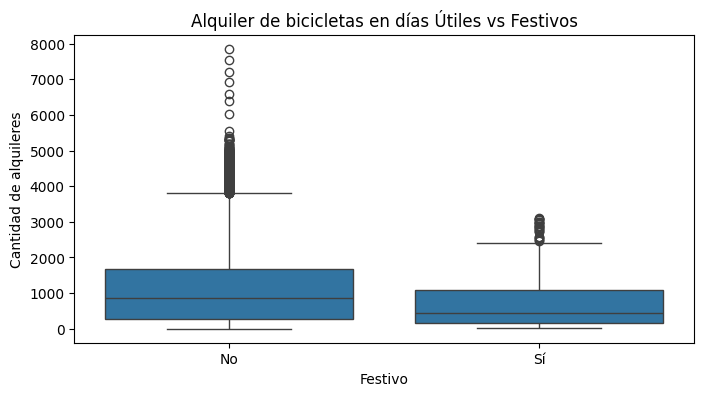

In [25]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df_limpio, x='festivo',y='conteo')
plt.title('Alquiler de bicicletas en días Útiles vs Festivos')
plt.xlabel('Festivo')
plt.ylabel('Cantidad de alquileres')
plt.show()

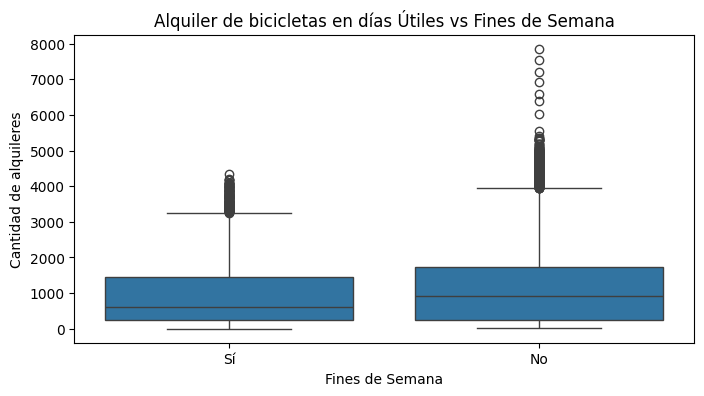

In [26]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df_limpio, x='fin_de_semana',y='conteo')
plt.title('Alquiler de bicicletas en días Útiles vs Fines de Semana')
plt.xlabel('Fines de Semana')
plt.ylabel('Cantidad de alquileres')
plt.show()

In [27]:
mediana_festivo = df_limpio.groupby('festivo')['conteo'].median()
mediana_fin_de_semana = df_limpio.groupby('fin_de_semana')['conteo'].median()

In [28]:
mediana_festivo

,conteo
festivo,
No,855.0
Sí,439.5


In [29]:
mediana_fin_de_semana

,conteo
fin_de_semana,
No,927.0
Sí,619.0


###**Investigando cómo el clima afecta la demanda**

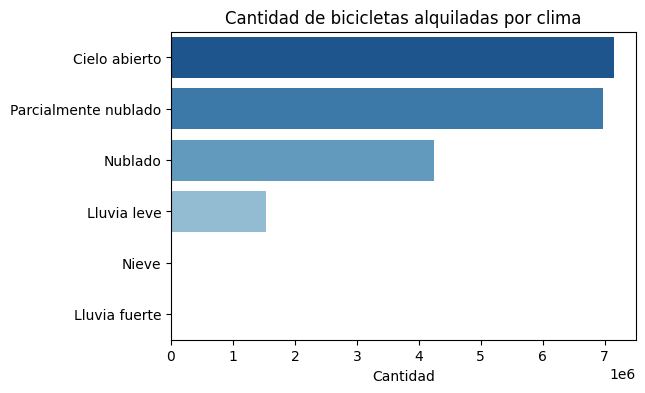

In [30]:
df_clima = df_limpio.groupby('clima')['conteo'].sum().reset_index().sort_values(by='conteo',ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(data=df_clima, y='clima',x='conteo',hue='clima',palette='Blues_r',orient='h')
plt.title('Cantidad de bicicletas alquiladas por clima')
plt.xlabel('Cantidad')
plt.ylabel('')
plt.show()

In [31]:
df_clima

,clima,conteo
0,Cielo abierto,7146847
5,Parcialmente nublado,6965558
4,Nublado,4243887
2,Lluvia leve,1526461
3,Nieve,15051
1,Lluvia fuerte,8168


###**Analizando las distribuciones por estación**

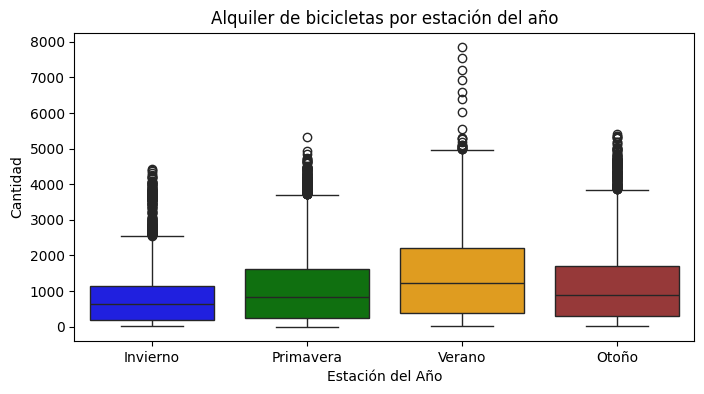

In [32]:
plt.figure(figsize=(8,4))
paleta_colores = {'Primavera': 'green', 'Verano': 'orange', 'Otoño': 'brown' , 'Invierno': 'blue'}
sns.boxplot(x='estacion',y='conteo',data=df_limpio,hue='estacion',palette=paleta_colores)
plt.title('Alquiler de bicicletas por estación del año')
plt.xlabel('Estación del Año')
plt.ylabel('Cantidad')
plt.show()

In [33]:
df_limpio.groupby('estacion')['conteo'].median()

,conteo
estacion,
Invierno,632.0
Otoño,898.0
Primavera,823.0
Verano,1214.0


Formulando las hipótesis:

$H_0:$ Las distribuciones son iguales.\
$H_1:$ Las distribuciones son diferentes.

> Encuentra la documentación detallada sobre *mannwhitneyu* de la biblioteca scipy [aquí](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html).

In [34]:
from scipy.stats import mannwhitneyu

primavera = df_limpio[df_limpio['estacion']=='Primavera']['conteo']
otono = df_limpio[df_limpio['estacion']=='Otoño']['conteo']

u_statistic,p_value = mannwhitneyu(primavera,otono,alternative='two-sided')
u_statistic,p_value

(np.float64(9044682.5), np.float64(0.0004762100221646296))

El *p value* menor que 0.05 sugiere que los resultados observados son improbables de ocurrir solo por azar. Por lo tanto, rechazamos la hipótesis nula en favor de la hipótesis alternativa, concluyendo que existen evidencias estadísticamente significativas para respaldar la hipótesis alternativa.

##**Clase 4: Analizando datos a lo largo del tiempo**

###**Convirtiendo tipos de datos**

In [35]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha_hora         17414 non-null  object 
 1   conteo             17414 non-null  int64  
 2   temperatura        17414 non-null  float64
 3   sensacion_termica  17414 non-null  float64
 4   humedad            17414 non-null  float64
 5   velocidad_viento   17414 non-null  float64
 6   clima              17414 non-null  object 
 7   festivo            17414 non-null  object 
 8   fin_de_semana      17414 non-null  object 
 9   estacion           17414 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 1.5+ MB


In [36]:
df_fecha = df_limpio.copy()

In [37]:
df_fecha['fecha_hora'] = pd.to_datetime(df_fecha['fecha_hora'])
df_fecha.head()

,fecha_hora,conteo,temperatura,sensacion_termica,humedad,velocidad_viento,clima,festivo,fin_de_semana,estacion
0,2023-01-04 00:00:00,182,3.00,2.00,93.0,6.0,Nublado,No,Sí,Invierno
1,2023-01-04 01:00:00,138,2.75,2.25,93.0,5.0,Cielo abierto,No,Sí,Invierno
2,2023-01-04 02:00:00,134,2.50,2.50,96.5,0.0,Cielo abierto,No,Sí,Invierno
3,2023-01-04 03:00:00,72,2.00,2.00,100.0,0.0,Cielo abierto,No,Sí,Invierno
4,2023-01-04 04:00:00,47,2.00,2.00,93.0,6.5,Cielo abierto,No,Sí,Invierno


In [39]:
df_fecha.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha_hora         17414 non-null  datetime64[ns]
 1   conteo             17414 non-null  int64         
 2   temperatura        17414 non-null  float64       
 3   sensacion_termica  17414 non-null  float64       
 4   humedad            17414 non-null  float64       
 5   velocidad_viento   17414 non-null  float64       
 6   clima              17414 non-null  object        
 7   festivo            17414 non-null  object        
 8   fin_de_semana      17414 non-null  object        
 9   estacion           17414 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(4)
memory usage: 1.5+ MB


In [40]:
df_fecha['mes'] = df_fecha['fecha_hora'].dt.month
df_fecha['horario'] = df_fecha['fecha_hora'].dt.hour

In [41]:
df_fecha.head()

,fecha_hora,conteo,temperatura,sensacion_termica,humedad,velocidad_viento,clima,festivo,fin_de_semana,estacion,mes,horario
0,2023-01-04 00:00:00,182,3.00,2.00,93.0,6.0,Nublado,No,Sí,Invierno,1,0
1,2023-01-04 01:00:00,138,2.75,2.25,93.0,5.0,Cielo abierto,No,Sí,Invierno,1,1
2,2023-01-04 02:00:00,134,2.50,2.50,96.5,0.0,Cielo abierto,No,Sí,Invierno,1,2
3,2023-01-04 03:00:00,72,2.00,2.00,100.0,0.0,Cielo abierto,No,Sí,Invierno,1,3
4,2023-01-04 04:00:00,47,2.00,2.00,93.0,6.5,Cielo abierto,No,Sí,Invierno,1,4


In [42]:
df_fecha['fecha_hora'] = df_fecha['fecha_hora'].dt.date
df_fecha.head()

In [47]:
df_fecha.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17414 entries, 0 to 17413
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha_hora         17414 non-null  object 
 1   conteo             17414 non-null  int64  
 2   temperatura        17414 non-null  float64
 3   sensacion_termica  17414 non-null  float64
 4   humedad            17414 non-null  float64
 5   velocidad_viento   17414 non-null  float64
 6   clima              17414 non-null  object 
 7   festivo            17414 non-null  object 
 8   fin_de_semana      17414 non-null  object 
 9   estacion           17414 non-null  object 
 10  mes                17414 non-null  int32  
 11  horario            17414 non-null  int32  
dtypes: float64(4), int32(2), int64(1), object(5)
memory usage: 2.1+ MB


In [48]:
df_fecha['fecha_hora'] = pd.to_datetime(df_fecha['fecha_hora'])
df_fecha = df_fecha.rename(columns={'fecha_hora':'fecha'})
df_fecha.head()

,fecha,conteo,temperatura,sensacion_termica,humedad,velocidad_viento,clima,festivo,fin_de_semana,estacion,mes,horario
0,2023-01-04,182,3.00,2.00,93.0,6.0,Nublado,No,Sí,Invierno,1,0
1,2023-01-04,138,2.75,2.25,93.0,5.0,Cielo abierto,No,Sí,Invierno,1,1
2,2023-01-04,134,2.50,2.50,96.5,0.0,Cielo abierto,No,Sí,Invierno,1,2
3,2023-01-04,72,2.00,2.00,100.0,0.0,Cielo abierto,No,Sí,Invierno,1,3
4,2023-01-04,47,2.00,2.00,93.0,6.5,Cielo abierto,No,Sí,Invierno,1,4


In [49]:
df_fecha.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17414 entries, 0 to 17413
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              17414 non-null  datetime64[ns]
 1   conteo             17414 non-null  int64         
 2   temperatura        17414 non-null  float64       
 3   sensacion_termica  17414 non-null  float64       
 4   humedad            17414 non-null  float64       
 5   velocidad_viento   17414 non-null  float64       
 6   clima              17414 non-null  object        
 7   festivo            17414 non-null  object        
 8   fin_de_semana      17414 non-null  object        
 9   estacion           17414 non-null  object        
 10  mes                17414 non-null  int32         
 11  horario            17414 non-null  int32         
dtypes: datetime64[ns](1), float64(4), int32(2), int64(1), object(4)
memory usage: 2.1+ MB


###**Analizando la demanda por horario**

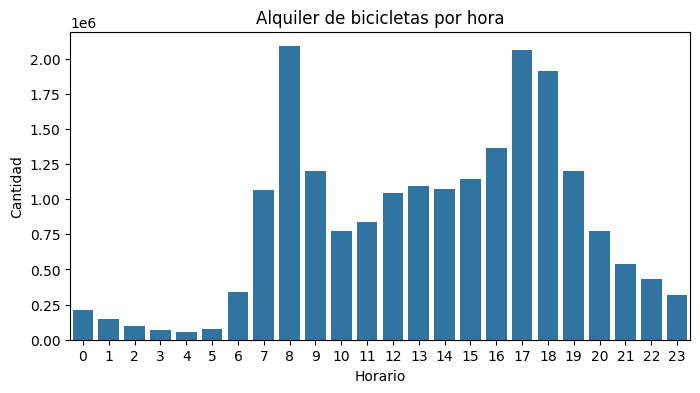

In [50]:
df_por_hora = df_fecha.groupby('horario')['conteo'].sum().reset_index()

plt.figure(figsize=(8,4))
sns.barplot(x='horario',y='conteo',data=df_por_hora)
plt.title('Alquiler de bicicletas por hora')
plt.xlabel('Horario')
plt.ylabel('Cantidad')
plt.show()

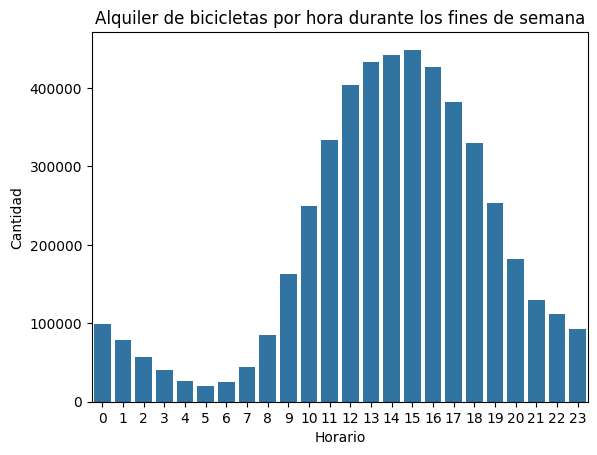

In [51]:
df_fin_de_semana = df_fecha[df_fecha['fin_de_semana']=='Sí']

alquiler_fin_de_semana = df_fin_de_semana.groupby('horario')['conteo'].sum().reset_index()
sns.barplot(x='horario',y='conteo',data=alquiler_fin_de_semana)
plt.title('Alquiler de bicicletas por hora durante los fines de semana')
plt.xlabel('Horario')
plt.ylabel('Cantidad')
plt.show()

###**Analizando la demanda por día y mes**

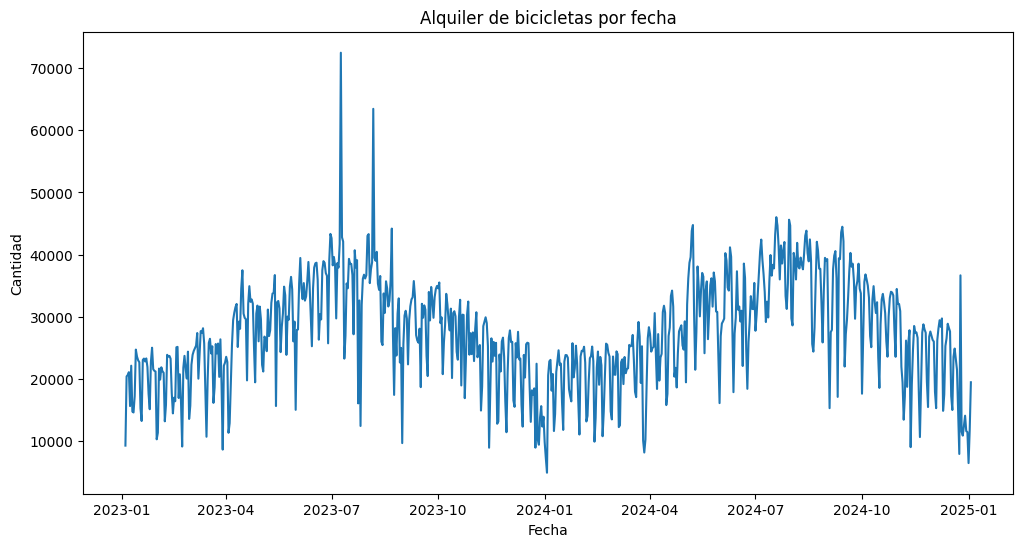

In [52]:
df_tiempo = df_fecha.groupby('fecha')['conteo'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=df_tiempo, x='fecha',y='conteo')
plt.title('Alquiler de bicicletas por fecha')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.show()

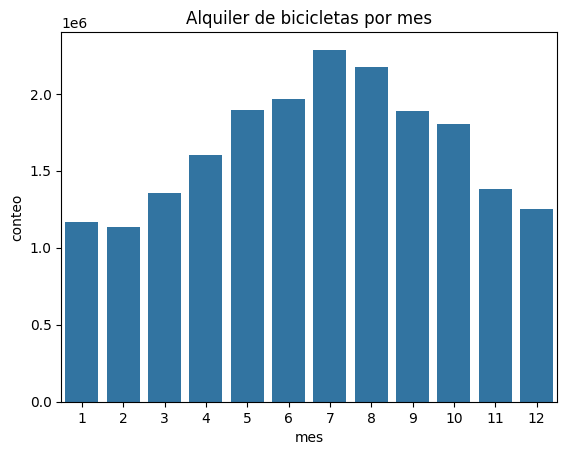

In [53]:
alquileres_mensuales = df_fecha.groupby('mes')['conteo'].sum().reset_index()

sns.barplot(data=alquileres_mensuales, x='mes',y='conteo')
plt.title('Alquiler de bicicletas por mes')
plt.show()

##**Clase 5: Construyendo el modelo predictivo**

###**Realizando la previsión**

> Consulta la documentación de la biblioteca Prophet [aquí](https://facebook.github.io/prophet/).

In [54]:
from prophet import Prophet

In [55]:
df_prophet = df_fecha[['fecha','conteo']].rename(columns={'fecha':'ds','conteo':'y'})
df_prophet.head()

,ds,y
0,2023-01-04,182
1,2023-01-04,138
2,2023-01-04,134
3,2023-01-04,72
4,2023-01-04,47


In [56]:
df_prophet = df_prophet.groupby('ds')['y'].sum().reset_index()
df_prophet.head()

,ds,y
0,2023-01-04,9234
1,2023-01-05,20372
2,2023-01-06,20613
3,2023-01-07,21064
4,2023-01-08,15601


In [57]:
import numpy as np

np.random.seed(4587)
modelo = Prophet()
modelo.fit(df_prophet)
futuro = modelo.make_future_dataframe(periods=90,freq='D')
prevision = modelo.predict(futuro)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


###**Explorando los resultados de la previsión**

In [58]:
prevision[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2023-01-04,10896.467270,4321.581515,17109.482391
1,2023-01-05,15307.714881,8961.189621,22574.191210
2,2023-01-06,18011.976032,11877.271651,24360.391322
3,2023-01-07,18743.547545,12394.423553,25310.506998
4,2023-01-08,19556.222421,12864.063277,25971.691336
...,...,...,...,...
815,2025-03-30,27345.508481,20974.820132,34387.734315
816,2025-03-31,25573.270442,19437.107199,32025.641680
817,2025-04-01,21256.930875,15529.682831,27696.267762
818,2025-04-02,20940.195428,14834.136190,27209.480399


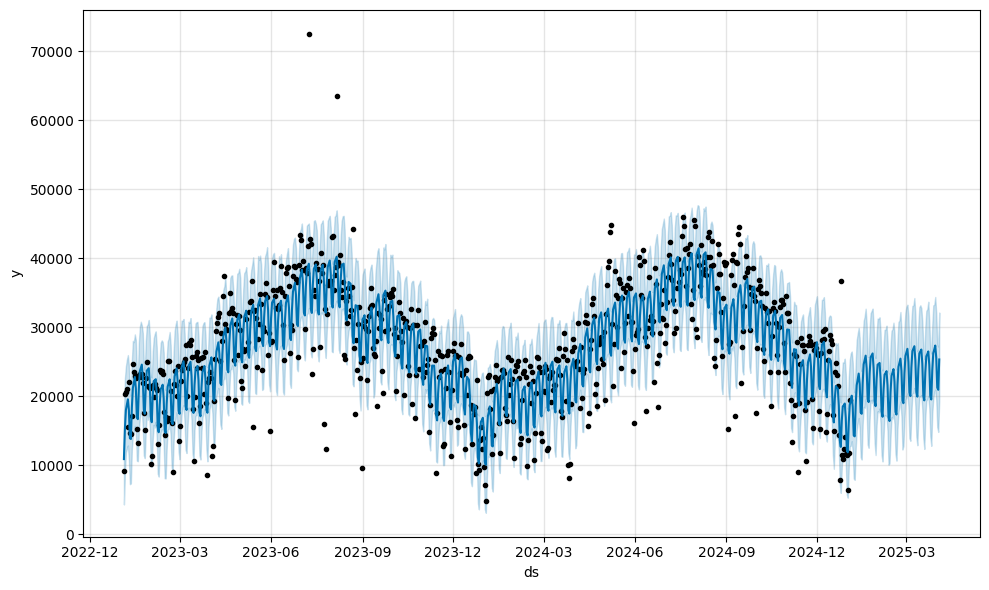

In [59]:
fig1 = modelo.plot(prevision)

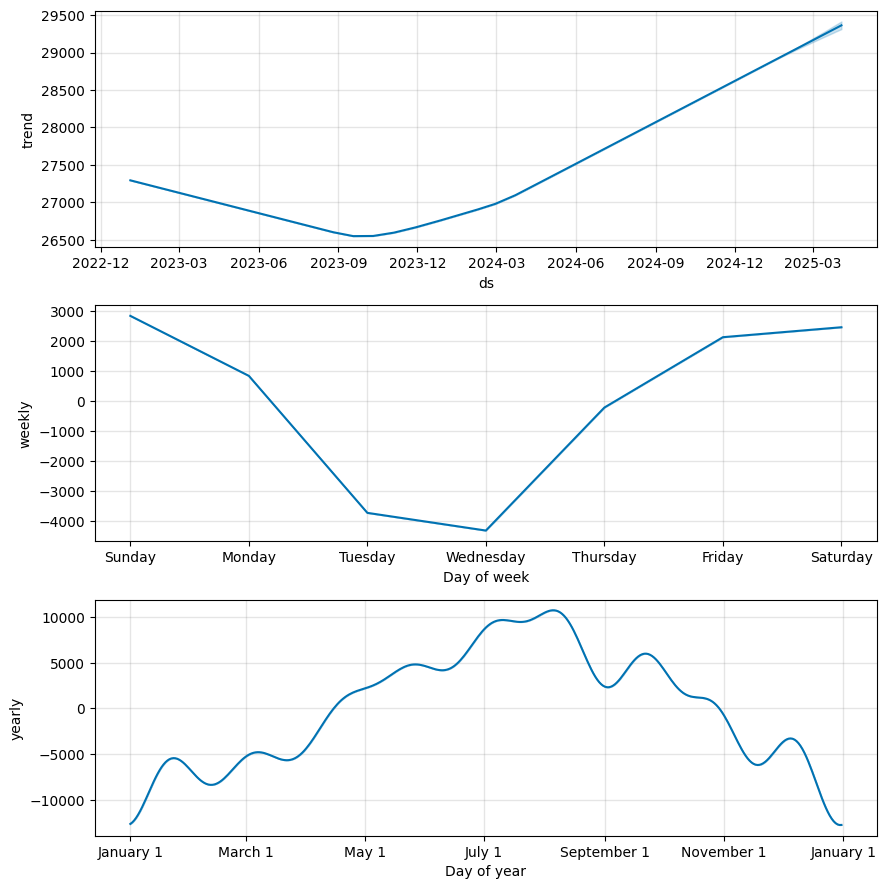

In [60]:
fig2 = modelo.plot_components(prevision)

La biblioteca Prophet utiliza un modelo aditivo que incluye componentes estacionales y de tendencia. La ecuación utilizada por Prophet para realizar predicciones puede representarse de la siguiente forma:

$y(t) = g(t) + s(t) + h(t) + \epsilon_t$

Donde:

- $y(t)$ es el valor observado en la serie temporal en el tiempo \( t \).
- $g(t)$ es la componente de tendencia que modela cambios de largo plazo.
- $s(t)$ es la componente estacional que modela patrones periódicos o estacionales.
- $h(t)$ es la componente de efecto de feriados.
- $\epsilon_t$ es el error aleatorio en la predicción.

Cada una de estas componentes se modela por separado. La componente de tendencia, $g(t)$, se modela frecuentemente como una función logística o polinómica. La componente estacional, $s(t)$, se modela utilizando el análisis de Fourier para capturar patrones periódicos. La componente de feriados, $h(t)$, se modela como un efecto aditivo para cada feriado especificado.

Por lo tanto, la ecuación completa utilizada por Prophet para realizar predicciones es una suma de estos componentes más el error aleatorio.

> Aunque en nuestro proyecto no hemos detallado la inclusión de los feriados en el modelo, es importante resaltar que esta posibilidad existe.


###**Separando los datos para entrenamiento y prueba**

Separar los datos en conjuntos de entrenamiento y prueba es fundamental en modelos de series temporales para evaluar la capacidad de generalización del modelo. Imagina que estás entrenando un modelo para predecir el número de ventas de una empresa. Si entrenas el modelo con todos los datos disponibles y luego lo pruebas con los mismos datos, puede parecer excelente, pero en la práctica puede fallar al predecir el futuro.

Esto sucede porque el modelo puede simplemente memorizar los patrones específicos de los datos de entrenamiento, sin realmente aprender a identificar patrones generales que se apliquen a nuevos datos. Al separar los datos en entrenamiento y prueba, simulas el escenario de predicción futura, garantizando que el modelo sea evaluado en su capacidad de generalización, es decir, en su habilidad para hacer predicciones precisas en datos que nunca ha visto antes. Esto ayuda a garantizar que el modelo sea robusto y confiable cuando se utilice para hacer predicciones en el mundo real.

In [61]:
df_prophet.shape

(730, 2)

In [66]:
df_entrenamiento = pd.DataFrame()
df_entrenamiento['ds'] =  df_prophet['ds'][:584]
df_entrenamiento['y'] =  df_prophet['y'][:584]

In [67]:
df_test = pd.DataFrame()
df_test['ds'] =  df_prophet['ds'][584:]
df_test['y'] =  df_prophet['y'][584:]

In [68]:
np.random.seed(4587)
modelo=Prophet()
modelo.fit(df_entrenamiento)
futuro = modelo.make_future_dataframe(periods=150,freq='D')
prevision = modelo.predict(futuro)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


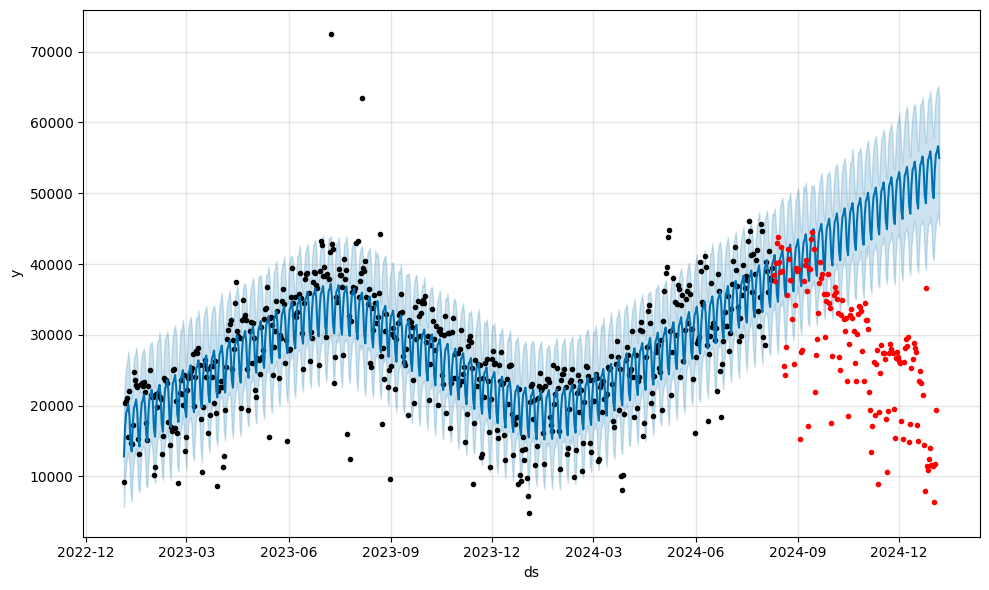

In [69]:
fig1 = modelo.plot(prevision)
plt.plot(df_test['ds'],df_test['y'],'.r')

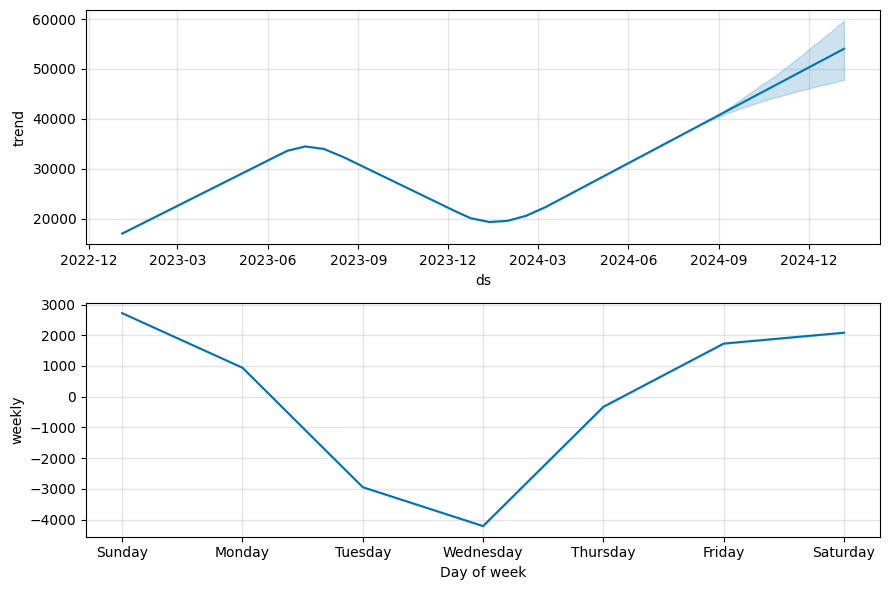

In [70]:
fig2 = modelo.plot_components(prevision)

###**Obteniendo las métricas**

In [71]:
df_prevision = prevision[['ds','yhat']]
df_comparacion = pd.merge(df_prevision,df_test,on='ds')
df_comparacion

,ds,yhat,y
0,2024-08-10,40543.422254,38430
1,2024-08-11,41283.839175,37626
2,2024-08-12,39613.357629,40159
3,2024-08-13,35831.631344,43041
4,2024-08-14,34670.342069,43848
...,...,...,...
141,2024-12-30,54250.929930,11566
142,2024-12-31,50469.203646,11424
143,2025-01-01,49307.914371,6421
144,2025-01-02,53293.101371,11823


La métrica MSE *(Mean Squared Error)* es una medida común de evaluación del desempeño para modelos de regresión y predicción. Calcula el promedio de los cuadrados de las diferencias entre los valores previstos por el modelo y los valores reales observados en los datos de prueba. Matemáticamente, el MSE se calcula mediante la fórmula:

$MSE = \frac{\sum_{} (y_i - \hat{y}_i)^2}{n}$

Sin embargo, el MSE tiene una limitación: sus unidades son cuadráticas con respecto a las unidades originales de los datos. Esto puede dificultar la interpretación de su valor.

Para superar esta limitación, muchas veces es preferible usar el RMSE *(Root Mean Squared Error)*. El RMSE es simplemente la raíz cuadrada del MSE y se calcula mediante la fórmula:

$RMSE = \sqrt{MSE}$


In [72]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(df_comparacion['y'],df_comparacion['yhat'])
rmse = np.sqrt(mse)

print(f'El valor del Error Cuadrático Medio (MSE) es de: {mse}\nEl valor de la raiz del Error Cuadrático Medio (RMSE) es de: {rmse}')

El valor del Error Cuadrático Medio (MSE) es de: 458673662.92687863
El valor de la raiz del Error Cuadrático Medio (RMSE) es de: 21416.667876373267


##**Clase 6: Mejorando las previsiones**

###**Ajustando los datos**

In [73]:
np.random.seed(4587)
modelo=Prophet(yearly_seasonality=True)
modelo.fit(df_entrenamiento)
futuro = modelo.make_future_dataframe(periods=150,freq='D')
prevision = modelo.predict(futuro)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


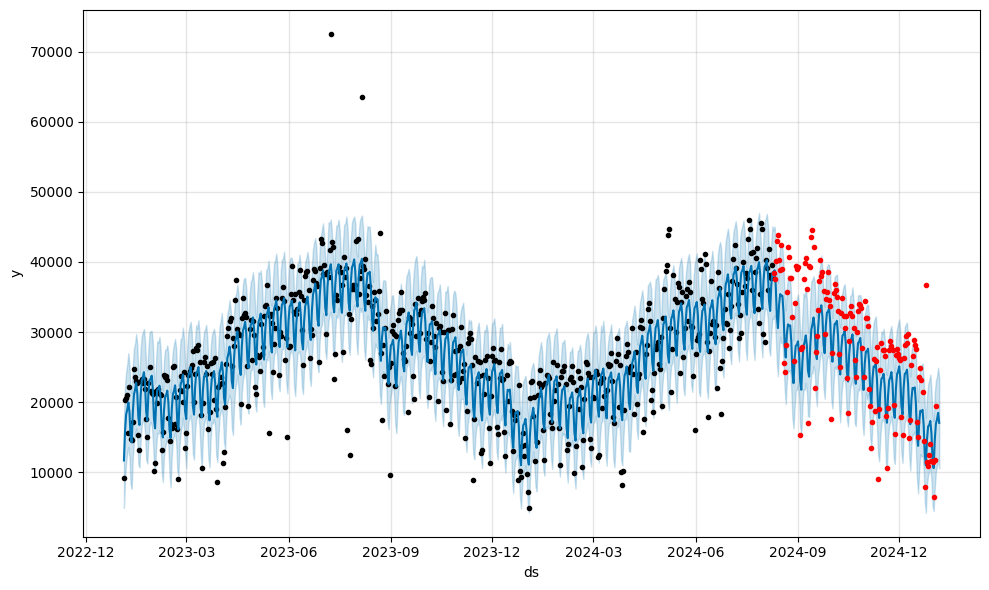

In [74]:
fig1 = modelo.plot(prevision)
plt.plot(df_test['ds'],df_test['y'],'.r')

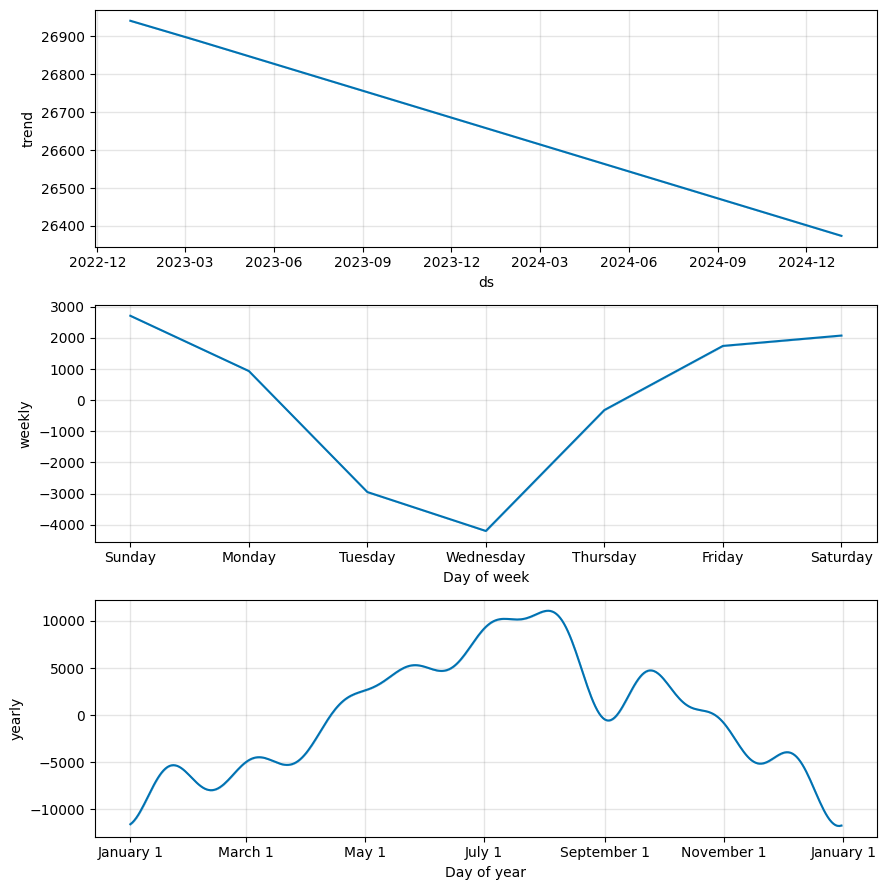

In [75]:
fig2 = modelo.plot_components(prevision)

In [77]:
df_prevision = prevision[['ds','yhat']]
df_comparacion = pd.merge(df_prevision,df_test,on='ds')
df_comparacion

,ds,yhat,y
0,2024-08-10,38527.542134,38430
1,2024-08-11,38811.057818,37626
2,2024-08-12,36635.991305,40159
3,2024-08-13,32304.210307,43041
4,2024-08-14,30563.757509,43848
...,...,...,...
141,2024-12-30,15551.457513,11566
142,2024-12-31,11726.103042,11424
143,2025-01-01,10593.051033,6421
144,2025-01-02,14647.067098,11823


In [78]:
mse = mean_squared_error(df_comparacion['y'],df_comparacion['yhat'])
rmse = np.sqrt(mse)

print(f'El valor del Error Cuadrático Medio (MSE) es de: {mse}\nEl valor de la raiz del Error Cuadrático Medio (RMSE) es de: {rmse}')

El valor del Error Cuadrático Medio (MSE) es de: 38109932.759134956
El valor de la raiz del Error Cuadrático Medio (RMSE) es de: 6173.3242875403


###**Tratando los outliers**

In [79]:
df_prophet

,ds,y
0,2023-01-04,9234
1,2023-01-05,20372
2,2023-01-06,20613
3,2023-01-07,21064
4,2023-01-08,15601
...,...,...
725,2024-12-30,11566
726,2024-12-31,11424
727,2025-01-01,6421
728,2025-01-02,11823


In [80]:
np.random.seed(4587)

modelo = Prophet()
modelo.fit(df_prophet)
futuro = modelo.make_future_dataframe(periods=0)
prevision = modelo.predict(futuro)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [81]:
sin_outliers = df_prophet[(df_prophet['y'] > prevision['yhat_lower']) & (df_prophet['y'] < prevision['yhat_upper'])]

In [82]:
sin_outliers

,ds,y
0,2023-01-04,9234
1,2023-01-05,20372
2,2023-01-06,20613
3,2023-01-07,21064
4,2023-01-08,15601
...,...,...
725,2024-12-30,11566
726,2024-12-31,11424
727,2025-01-01,6421
728,2025-01-02,11823


In [85]:
df_entrenamiento = pd.DataFrame()
df_entrenamiento['ds'] =  sin_outliers['ds'][:505]
df_entrenamiento['y'] =  sin_outliers['y'][:505]
df_test = pd.DataFrame()
df_test['ds'] =  sin_outliers['ds'][505:]
df_test['y'] =  sin_outliers['y'][505:]

###**Entrenando con los datos tratados**

In [86]:
np.random.seed(4587)
modelo_sin_outliers=Prophet(yearly_seasonality=True)
modelo_sin_outliers.fit(df_entrenamiento)
futuro = modelo_sin_outliers.make_future_dataframe(periods=150,freq='D')
prevision = modelo_sin_outliers.predict(futuro)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


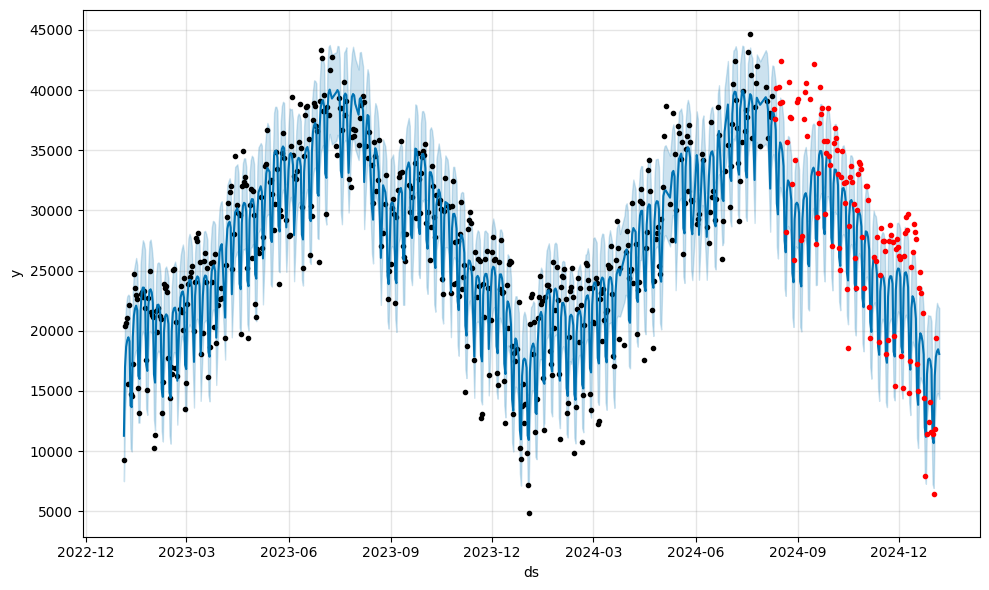

In [87]:
fig1 = modelo_sin_outliers.plot(prevision)
plt.plot(df_test['ds'], df_test['y'], '.r')

In [88]:
df_prevision = prevision[['ds', 'yhat']]
df_comparacion = pd.merge(df_prevision, df_test, on='ds')
df_comparacion

,ds,yhat,y
0,2024-08-10,38141.221495,38430
1,2024-08-11,37726.206298,37626
2,2024-08-12,36681.863676,40159
3,2024-08-15,34710.599995,40236
4,2024-08-16,35652.199233,38911
...,...,...,...
120,2024-12-30,16780.328248,11566
121,2024-12-31,11074.060855,11424
122,2025-01-01,10655.614786,6421
123,2025-01-02,16260.111767,11823


In [89]:
mse = mean_squared_error(df_comparacion['y'],df_comparacion['yhat'])
rmse = np.sqrt(mse)

print(f'El valor del Error Cuadrático Medio (MSE) es de: {mse}\nEl valor de la raiz del Error Cuadrático Medio (RMSE) es de: {rmse}')

El valor del Error Cuadrático Medio (MSE) es de: 15625683.80538115
El valor de la raiz del Error Cuadrático Medio (RMSE) es de: 3952.933569563388


###**Expandiendo el período de previsión**

In [90]:
np.random.seed(4587)
modelo_sin_outliers=Prophet(yearly_seasonality=True)
modelo_sin_outliers.fit(df_entrenamiento)
futuro = modelo_sin_outliers.make_future_dataframe(periods=365,freq='D')
prevision = modelo_sin_outliers.predict(futuro)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [91]:
from prophet.plot import plot_plotly

In [92]:
fig = plot_plotly(modelo_sin_outliers,prevision)
fig.show()